In [3]:
# matplotlib inline

import os
import sys
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn import tree

***
# Hello!

To get the full dataset from CIC, I used wget:
`wget -r -np -A '*.csv' http://cicresearch.ca/IOTDataset/CIC_IOT_Dataset2023/Dataset/CSV/` <-- the accual dataset...

***
# Dataset Creation:

## Dataset Functions:

In [2]:
def create_class_df(binary_label: int, multiclass_small_label: int, multiclass_big_label: int, file: str, subfile = None, max_subfiles: int = 100):

    # Check mandatory variables
    if file is None:
        print("[!] Error: label and file path are required.")
        return None
    
    targets = subfile if subfile else [""]
    dfs = []
    start_time = time.perf_counter() # Start time to measure how long the df creation takes
    data_name = file.rsplit("/", 1)[1]

    first_file_path = f"{file}{targets[0]}.csv"
    if os.path.exists(first_file_path):
        sample = pd.read_csv(first_file_path, nrows=0)
        all_cols = sample.columns.tolist()
        # Columns to drop up front:
        # Packet Based features: 
        #   - steram, mac, and ip are unrealistic
        #   - http_host is only 'none'
        #   - handshake_cipersuites is only '-1' 
        # Flow Based features:
        #   - Flow ID, Src IP, Dst IP are unrealistic
        #   - Label is added later in the dataset processing
        #   - Timestamp cannot be encoded?
        drop_cols = ["stream", "src_mac", "dst_mac", "src_ip", "dst_ip", "http_host", "handshake_ciphersuites", "Flow ID", "Src IP", "Dst IP", "Label", "Timestamp"]
        # Only keep columns that are NOT in our drop list
        keep_cols = [col for col in all_cols if col not in drop_cols]
    else:
        print("[!] Error: Initial file not found.")
        return None

    for subtype in targets:
        i = 0
        while True:
            # too many .csv files, breaks RAM limits on 32GB systems...
            if(i > max_subfiles):
                break
            # Handle naming: first file is often name.csv, subsequent are name1.csv, name2.csv...
            suffix = "" if i == 0 else str(i)
            file_path = f"{file}{subtype}{suffix}.csv"

            print(f"\r[*] Processing {file_path.rsplit("/", 1)[-1]}....".ljust(100), end="", flush=True)
           
            # Check if the file exists before trying to read it
            if os.path.exists(file_path):
                df = pd.read_csv(file_path, usecols=keep_cols, engine='pyarrow')
                dfs.append(df)
                i += 1
        
            else:
                # No more files for this subtype, break the while loop
                break

    if not dfs:
        print(f"No files found for path: {file}")
        return None

    # Combine everything into one dataframe
    print(f"\r[*] Concatenating {len(dfs)} dataframes...".ljust(100), end="", flush=True)

    df = pd.concat(dfs, ignore_index=True)
    df["binary_label"] = binary_label
    df["multiclass_small_label"] = multiclass_small_label
    df["multiclass_big_label"] = multiclass_big_label

    # Final memory optimization: Downcast numeric types
    # This turns 64-bit numbers into 32-bit where possible
    fcols = df.select_dtypes('float').columns
    icols = df.select_dtypes('integer').columns
    df[fcols] = df[fcols].apply(pd.to_numeric, downcast='float')
    df[icols] = df[icols].apply(pd.to_numeric, downcast='integer')

    # Measure and print how long df creation took
    elapsed_time = time.perf_counter() - start_time
    print(f"\r[+] {data_name} Done! Processing took: {elapsed_time:.6f} seconds".ljust(100))

    return df

In [3]:
def combine_class_dfs(dfs_list: list, entries: int, random_state: int = 0, save_as_csv: str = None):
    
    # Check mandatory variable
    if dfs_list is None or entries is None:
        print("Error: list of dfs and number of entries in final df is required.")
        return None
    
    entries_per_df = round(entries / len(dfs_list))
    main_df = pd.DataFrame()
    processed_list = []

    # Start time of the main function to measure how long the concat + preprocessing takes
    start_time = time.perf_counter()

    # Main concat function
    for i, df in enumerate(dfs_list):
        print(f"\r[*] Processing dataframe #{i}...".ljust(100), end="", flush=True)

        # min() ensures we don't crash if a DF has fewer rows than requested
        n_samples = min(len(df), entries_per_df)
        if (n_samples < entries_per_df):
            print(f"\r[!] Not enough rows in class {df["label"].iloc[0]}, using all {n_samples} rows.".ljust(100), flush=True)

        processed_list.append(df.sample(n=n_samples, random_state=random_state))

    print(f"\r[*] Concatenating dataframes...".ljust(100), end="", flush=True)
    main_df = pd.concat(processed_list, ignore_index=True)

    # Preprocessing: Encoding and Normalization
    target_col = "label"
    features = main_df.columns.drop(target_col) if target_col in main_df.columns else main_df.columns

    # Replace all NaN values with 0
    print(f"\r[*] Filling NaN values with 0...".ljust(100), end="", flush=True)
    main_df = main_df.fillna(0)

    # Encoding using OrdinalEncoder()
    object_cols = main_df[features].select_dtypes(include=["object", "category"]).columns
    if not object_cols.empty:
        print(f"\r[*] Encoding non-integer values...".ljust(100), end="", flush=True)

        encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        main_df[object_cols] = encoder.fit_transform(main_df[object_cols])

    # Normalization using MinMaxScaler()
    print(f"\r[*] Normalizing values to range [0, 1]...".ljust(100), end="", flush=True)

    scaler = MinMaxScaler()
    main_df[features] = scaler.fit_transform(main_df[features])

    # Save to .csv if True
    if save_as_csv:
        print(f"\r[*] Saving dataframe to {save_as_csv}.csv...".ljust(100), end="", flush=True)
        main_df.to_csv(f"{save_as_csv}.csv")

    # Measure and print how long concat + preprocessing took
    elapsed_time = time.perf_counter() - start_time
    print(f"\r[+] Done! Processing took: {elapsed_time:.6f} seconds".ljust(100))

    return main_df


***

In [4]:
    # === Benign ===
df_benign_p = create_class_df(0, 0, 0, 
    "Dataset/Device Identification_Anomaly Detection - Packet Based Features/BenignTraffic/BenignTraffic")

[+] BenignTraffic Done! Processing took: 8.563510 seconds                                          


In [5]:
# === Brute Force ===
df_bruteforce_p = create_class_df(1, 1, 1, 
    "Dataset/Device Identification_Anomaly Detection - Packet Based Features/BruteForce/DictionaryBruteForce/DictionaryBruteForce")

[+] DictionaryBruteForce Done! Processing took: 0.931027 seconds                                   


In [6]:
# === DDoS ===
# ACK Fragmentation
df_ddos_ack_p = create_class_df(1, 2, 2, 
    "Dataset/Device Identification_Anomaly Detection - Packet Based Features/DDoS/DDoS-ACK_Fragmentation/DDoS-ACK_Fragmentation")

# HTTP Flood
df_ddos_http_p = create_class_df(1, 2, 3, 
    "Dataset/Device Identification_Anomaly Detection - Packet Based Features/DDoS/DDoS-HTTP_Flood/DDoS-HTTP_Flood")

# ICMP Fragmentation
df_ddos_icmp_p = create_class_df(1, 2, 4, 
    "Dataset/Device Identification_Anomaly Detection - Packet Based Features/DDoS/DDoS-ICMP_Fragmentation/DDoS-ICMP_Fragmentation")

# SlowLoris
df_ddos_slow_p = create_class_df(1, 2, 5, 
    "Dataset/Device Identification_Anomaly Detection - Packet Based Features/DDoS/DDoS-SlowLoris/DDoS-SlowLoris")

# SynonymousIP Flood
df_ddos_syn_ip_p = create_class_df(1, 2, 6, 
    "Dataset/Device Identification_Anomaly Detection - Packet Based Features/DDoS/DDoS-SynonymousIP_Flood/DDoS-SynonymousIP_Flood")

# TCP Flood
df_ddos_tcp_p = create_class_df(1, 2, 7, 
    "Dataset/Device Identification_Anomaly Detection - Packet Based Features/DDoS/DDoS-TCP_Flood/DDoS-TCP_Flood")

# UDP Flood
df_ddos_udp_p = create_class_df(1, 2, 8, 
    "Dataset/Device Identification_Anomaly Detection - Packet Based Features/DDoS/DDoS-UDP_Flood/DDoS-UDP_Flood")

# UDP Fragmentation
df_ddos_udp_frag_p = create_class_df(1, 2, 9, 
    "Dataset/Device Identification_Anomaly Detection - Packet Based Features/DDoS/DDoS-UDP_Fragmentation/DDoS-UDP_Fragmentation")

# DDoS Binary and Small Mulitclass
df_ddos_p = pd.concat([df_ddos_ack_p, df_ddos_http_p, df_ddos_icmp_p, df_ddos_slow_p, df_ddos_syn_ip_p, df_ddos_tcp_p, df_ddos_udp_p, df_ddos_udp_frag_p], ignore_index=True)

[+] DDoS-ACK_Fragmentation Done! Processing took: 31.855969 seconds                                
[+] DDoS-HTTP_Flood Done! Processing took: 1.812373 seconds                                        
[+] DDoS-ICMP_Fragmentation Done! Processing took: 74.210824 seconds                               
[+] DDoS-SlowLoris Done! Processing took: 3.177740 seconds                                         
[+] DDoS-SynonymousIP_Flood Done! Processing took: 16.535808 seconds                               
[+] DDoS-TCP_Flood Done! Processing took: 8.442180 seconds                                         
[+] DDoS-UDP_Flood Done! Processing took: 31.065467 seconds                                        
[+] DDoS-UDP_Fragmentation Done! Processing took: 46.217801 seconds                                


In [7]:
# === DoS ===
# HTTP Flood
df_dos_http_p = create_class_df(1, 3, 10, 
    "Dataset/Device Identification_Anomaly Detection - Packet Based Features/DoS/DoS-HTTP_Flood/DoS-HTTP_Flood")

# SYN Flood
df_dos_syn_p = create_class_df(1, 3, 11, 
    "Dataset/Device Identification_Anomaly Detection - Packet Based Features/DoS/DoS-SYN_Flood/DoS-SYN_Flood")

# TCP Flood
df_dos_tcp_p = create_class_df(1, 3, 12, 
    "Dataset/Device Identification_Anomaly Detection - Packet Based Features/DoS/DoS-TCP_Flood/DoS-TCP_Flood")

# UDP Flood
df_dos_udp_p = create_class_df(1, 3, 13, 
    "Dataset/Device Identification_Anomaly Detection - Packet Based Features/DoS/DoS-UDP_Flood/DoS-UDP_Flood")

# DoS Binary and Small Mulitclass
df_dos_p = pd.concat([df_dos_http_p, df_dos_syn_p, df_dos_tcp_p, df_dos_udp_p], ignore_index=True)

[+] DoS-HTTP_Flood Done! Processing took: 4.610330 seconds                                         
[+] DoS-SYN_Flood Done! Processing took: 5.938961 seconds                                          
[+] DoS-TCP_Flood Done! Processing took: 7.048568 seconds                                          
[+] DoS-UDP_Flood Done! Processing took: 12.681858 seconds                                         


In [8]:
# === Botnet (Mirai) ===
df_botnet_p = create_class_df(1, 4, 14, 
    "Dataset/Device Identification_Anomaly Detection - Packet Based Features/Mirai/Mirai-greip_flood/Mirai-greip_flood")

[+] Mirai-greip_flood Done! Processing took: 108.084012 seconds                                    


In [9]:
# === Recon ===
# Host Discovery
df_recon_host_p = create_class_df(1, 5, 15, 
    "Dataset/Device Identification_Anomaly Detection - Packet Based Features/Recon/Recon-HostDiscovery/Recon-HostDiscovery")

# OSScan
df_recon_os_p = create_class_df(1, 5, 16, 
    "Dataset/Device Identification_Anomaly Detection - Packet Based Features/Recon/Recon-OSScan/Recon-OSScan")

# Ping Sweep
df_recon_ping_p = create_class_df(1, 5, 17, 
    "Dataset/Device Identification_Anomaly Detection - Packet Based Features/Recon/Recon-PingSweep/Recon-PingSweep")

# PortScan
df_recon_port_p = create_class_df(1, 5, 18, 
    "Dataset/Device Identification_Anomaly Detection - Packet Based Features/Recon/Recon-PortScan/Recon-PortScan")

# Vulnerability Scan
df_recon_vuln_p = create_class_df(1, 5, 19, 
    "Dataset/Device Identification_Anomaly Detection - Packet Based Features/Recon/VulnerabilityScan/VulnerabilityScan")

# Recon Binary and Small Mulitclass
df_recon_p = pd.concat([df_recon_host_p, df_recon_os_p, df_recon_ping_p, df_recon_port_p, df_recon_vuln_p], ignore_index=True)

[+] Recon-HostDiscovery Done! Processing took: 2.003223 seconds                                    
[+] Recon-OSScan Done! Processing took: 1.867361 seconds                                           
[+] Recon-PingSweep Done! Processing took: 0.195264 seconds                                        
[+] Recon-PortScan Done! Processing took: 1.943057 seconds                                         
[+] VulnerabilityScan Done! Processing took: 1.878456 seconds                                      


In [10]:
# === Spoofing ===
# DNS Spoofing
df_spoof_dns_p = create_class_df(1, 6, 20, 
    "Dataset/Device Identification_Anomaly Detection - Packet Based Features/Spoofing/DNS_Spoofing/DNS_Spoofing")

# MITM ARP Spoofing
df_spoof_mitm_p = create_class_df(1, 6, 21, 
    "Dataset/Device Identification_Anomaly Detection - Packet Based Features/Spoofing/MITM-ArpSpoofing/MITM-ArpSpoofing")

# Spoof Binary and Small Mulitclass
df_spoof_p = pd.concat([df_spoof_dns_p, df_spoof_mitm_p], ignore_index=True)

[+] DNS_Spoofing Done! Processing took: 1.881947 seconds                                           
[+] MITM-ArpSpoofing Done! Processing took: 4.338890 seconds                                       


In [11]:
# === Web-Based ===
# Backdoor Malware
df_web_backdoor_p = create_class_df(1, 7, 22, 
    "Dataset/Device Identification_Anomaly Detection - Packet Based Features/Web-Based/Backdoor_Malware/Backdoor_Malware")

# Browser Hijacking
df_web_browser_p = create_class_df(1, 7, 23, 
    "Dataset/Device Identification_Anomaly Detection - Packet Based Features/Web-Based/BrowserHijacking/BrowserHijacking")

# Command Injection
df_web_command_p = create_class_df(1, 7, 24, 
    "Dataset/Device Identification_Anomaly Detection - Packet Based Features/Web-Based/CommandInjection/CommandInjection")

# SQL Injection
df_web_sql_p = create_class_df(1, 7, 25, 
    "Dataset/Device Identification_Anomaly Detection - Packet Based Features/Web-Based/SqlInjection/SqlInjection")

# Uploading Attacks
df_web_uploading_p = create_class_df(1, 7, 26, 
    "Dataset/Device Identification_Anomaly Detection - Packet Based Features/Web-Based/Uploading_Attack/Uploading_Attack")

# XSS
df_web_xss_p = create_class_df(1, 7, 27, 
    "Dataset/Device Identification_Anomaly Detection - Packet Based Features/Web-Based/XSS/XSS")

# Web Binary and Small Mulitclass
df_web_p = pd.concat([df_web_backdoor_p, df_web_browser_p, df_web_command_p, df_web_sql_p, df_web_uploading_p, df_web_xss_p], ignore_index=True)

[+] Backdoor_Malware Done! Processing took: 0.517563 seconds                                       
[+] BrowserHijacking Done! Processing took: 0.414993 seconds                                       
[+] CommandInjection Done! Processing took: 0.328047 seconds                                       
[+] SqlInjection Done! Processing took: 0.290040 seconds                                           
[+] Uploading_Attack Done! Processing took: 0.109152 seconds                                       
[+] XSS Done! Processing took: 0.270349 seconds                                                    


***


In [ ]:
# === Full Dataset ===
df_full_p = pd.concat([df_benign_p, df_ddos_p, df_dos_p, df_botnet_p, df_recon_p, df_spoof_p, df_web_p], ignore_index=True)

In [ ]:
data_counts = df_full_p["binary_label"].value_counts()

plt.figure(figsize=(10, 6))

ax = data_counts.plot(kind='bar')
ax.bar_label(ax.containers[0], fmt='{:.0f}', rotation=25)

plt.xlabel("Classes", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.ticklabel_format(style='plain', axis='y')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

max big = 12924 (class 26)

max small = 253902 (class 7)

max binary = 1182798 (class 0)

In [12]:
# === Big Multiclass Classification Dataset ===
dfs_list = [df_benign_p, 
            df_bruteforce_p, 
            df_ddos_ack_p, df_ddos_http_p, df_ddos_icmp_p, df_ddos_slow_p, df_ddos_syn_ip_p, df_ddos_tcp_p, df_ddos_udp_p, df_ddos_udp_frag_p,
            df_dos_http_p, df_dos_syn_p, df_dos_tcp_p, df_dos_udp_p,
            df_botnet_p,
            df_recon_host_p, df_recon_os_p, df_recon_ping_p, df_recon_port_p, df_recon_vuln_p,
            df_spoof_dns_p, df_spoof_mitm_p, df_spoof_p, 
            df_web_backdoor_p, df_web_browser_p, df_web_command_p, df_web_sql_p, df_web_uploading_p, df_web_xss_p]

# Drop labels for smallmulticlass and binary datasets, and rename multiclass_small_label to label.
start_time = time.perf_counter()
print(f"[*] Preprocessing datasets for combination...".ljust(100), end="", flush=True)

dfs_list_clean = []
for df in dfs_list:
    df.drop(["binary_label", "multiclass_small_label"], axis=1, inplace=True)
    df.rename(columns={"multiclass_big_label": "label"}, inplace=True)
    dfs_list_clean.append(df)

elapsed_time = time.perf_counter() - start_time
print(f"\r[+] Done preprocessing datasets for combination! Processing took: {elapsed_time:.6f} seconds".ljust(100))

df_multi_big_n348948_p = combine_class_dfs(dfs_list=dfs_list, entries=348948)

df_multi_big_n348948_p.info(verbose=True)

[+] Done preprocessing datasets for combination! Processing took: 107.591562 seconds                
[+] Done! Processing took: 8.360924 seconds                                                        
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348957 entries, 0 to 348956
Data columns (total 129 columns):
 #    Column                                 Dtype  
---   ------                                 -----  
 0    src_port                               float64
 1    dst_port                               float64
 2    inter_arrival_time                     float64
 3    time_since_previously_displayed_frame  float64
 4    port_class_dst                         float64
 5    l4_tcp                                 float64
 6    l4_udp                                 float64
 7    ttl                                    float64
 8    eth_size                               float64
 9    tcp_window_size                        float64
 10   payload_entropy                        float6

In [ ]:
# === Small Multiclass Classification Dataset

In [ ]:
# === Binary Classification Dataset ===

***

# Dataset Exploration:

In [ ]:
# Correlation coefficients using Preasons Correlation Coefficient
correlation = df.corr()
print(correlation["label"].sort_values(ascending=False))

In [ ]:
# This removes the diagonal and the mirrored bottom half
upper = correlation.where(np.triu(np.ones(correlation.shape), k=1).astype(bool))

# This removes all the NaN values (the lower triangle)
high_corr = (upper.stack()
             .reset_index())

high_corr.columns = ['feature_1', 'feature_2', 'Correlation']

# 4 Filter for values > 0.9 and sort
high_corr_list = high_corr[high_corr['Correlation'] > 0.9].sort_values(by='Correlation', ascending=False)

high_corr_list

In [ ]:
# Correlation Heat Map
plt.figure(figsize=(100,100))
plt.title("Correlation of Attributes with 'Label' variable")
heatmap = sns.heatmap(correlation, square=True, annot=True, fmt='.2f', linecolor='white')
heatmap.set_xticklabels(heatmap.get_xticklabels(), rotation=90)
heatmap.set_yticklabels(heatmap.get_yticklabels(), rotation=20)           
plt.show()

***

# Model Training:

## Model Training Functions:

In [ ]:
def create_dtc(df, random_state: int = 0, folder: str = None):

    # Check mandatory variables
    if df is None:
        print("Error: dataset is required.")
        return None

    # Set global variables
    now = time.localtime()
    dtg = time.strftime("%y%m%d%H%M", now)
    date = time.strftime("%Y-%m-%d %H:%M", now)

    folder = f"" if not folder else f"{folder}/"

    # ----- Dataset processing -----
    print(f"\r[*] Processing dataset...".ljust(100), end="", flush=True)

    X = df.drop(['label'], axis=1)
    y = df['label']

    (X_train, X_test, y_train, y_test) = train_test_split(X, y, train_size=0.8, random_state=random_state)

    # ----- DecisionTreeClassifier creation -----
    print(f"\r[*] Training DecisionTreeClassifier...".ljust(100), end="", flush=True)
    dtc = DecisionTreeClassifier(random_state=random_state)
    
    start_time = time.perf_counter()
    dtc.fit(X_train, y_train)
    training_time = time.perf_counter() - start_time

    # ----- Save the model -----
    num_features = dtc.n_features_in_
    num_classes = dtc.n_classes_
    model_name = f"dtc_c{num_classes}_f{num_features:03d}_{dtg}"

    print(f"\r[+] Done! Model {model_name} trained in {training_time:.2} s".ljust(100), flush=True)
    print(f"\r[*] Saving the model as {model_name}.pkl".ljust(100), end="", flush=True)

    with open(f"{folder}{model_name}.pkl", "wb") as file:
        pickle.dump(dtc, file)

    # ----- Model report -----
    print(f"\r[*] Generating report for {model_name}".ljust(100), end="", flush=True)
    """
    Generates a comprehensive .txt report for the trained classifier.
    """

    # Calculate Predictions and Metrics
    y_pred = dtc.predict(X_test)
    accuracy = classification_report(y_test, y_pred, output_dict=True)
    report_text = classification_report(y_test, y_pred, digits=4)
    
    # Calculate Model Size in KB
    size_kb = sys.getsizeof(f"{model_name}.pkl") / 1024

    # Get model metadata
    param = dtc.get_params()
    depth = dtc.get_depth()
    leaves = dtc.get_n_leaves()

    report = classification_report(y_test, y_pred, output_dict=True)

    class_ids = [k for k in report.keys() if k.isdigit() or isinstance(k, int)]
    precision_list = [report[c]['precision'] for c in class_ids]
    recall_list    = [report[c]['recall'] for c in class_ids]
    f1_list        = [report[c]['f1-score'] for c in class_ids]
    
    # Process Feature Importances
    importances = pd.DataFrame({
        'Feature': X.columns,
        'Importance': dtc.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    # Write to _report.txt 
    report_filename = f"{folder}{model_name}_report.txt"
    with open(report_filename, 'w') as f:
        f.write(f"{'='*70}\n")
        f.write(f"Model Report: {model_name}\n")
        f.write(f"Model Creation: {date}\n")
        f.write(f"{'='*70}\n\n")

        f.write(f"--- CORE STATS ---\n")
        f.write(f"Training Time:    {training_time:.6f} s\n")
        f.write(f"Model Size:       {size_kb:.6f} KB\n")
        f.write(f"Total Features:   {dtc.n_features_in_}\n")
        f.write(f"Accuracy:         {accuracy['accuracy']:.4f}\n\n")

        f.write(f"--- DTC PRARAMETERS ---\n")
        f.write(f"Depth:            {depth}\n")
        f.write(f"Leaves:           {leaves}\n\n")

        f.write(f"--- CLASSIFICATION REPORT ---\n")
        f.write(report_text)
        f.write("\n")

        f.write(f"--- FEATURE IMPORTANCE  ---\n")
        f.write(importances.to_string(index=False))
        
        unused = importances[importances['Importance'] == 0]['Feature'].tolist()
        f.write(f"\n\n--- UNUSED FEATURES ({len(unused)}) ---\n")
        f.write(", ".join(unused) if unused else "None")
        f.write(f"\n\n{'='*70}\n")

        f.write(f"Parameters: {param}\n")
        f.write(f"\n")
        f.write(f"Results String: {model_name},{round(size_kb, 2)},{num_features},{round(report['accuracy'], 4)},{round(report['macro avg']['precision'], 4)},{round(report['macro avg']['recall'], 4)},{round(report['macro avg']['f1-score'], 4)},{precision_list},{recall_list},{f1_list},{depth},{leaves}")        
        
    print(f"\r[+] Success: Model and report ({report_filename}) generated", flush=True)
    return dtc

In [16]:
dtc = create_dtc(df_multi_big_n348948_p)

[+] Success: Model and report (dtc_c28_f128_2512272107_report.txt) generated                       


## Decision Tree (DT)

In [ ]:
dtc = create_dtc(df)

In [ ]:
# Load saved model
with open('dtc_c8_f128_2512231838.pkl', 'rb') as f:
    dtc = pickle.load(f)

## Random Forrest (RF):

In [48]:
import pandas as pd

df = pd.read_csv("dataset_flow_binary_n10000.csv", index_col=0)

df.replace([np.inf, -np.inf], 1, inplace=True)

X = df.drop(['label'], axis=1)
y = df['label']

(X_train, X_test, y_train, y_test) = train_test_split(X, y, train_size=0.8, random_state=0)

In [52]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(random_state=0)

start_time = time.process_time()
rfc.fit(X_train, y_train)
elapsed_time = time.process_time() - start_time
print(f"\r[+] Done!\nModel training time: {elapsed_time:.6f} seconds".ljust(100))

y_pred = rfc.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc:.4f}")
print(f"Model Report:")
print(classification_report(y_test, y_pred))

[+] Done!
Model training time: 2.296875 seconds                                                    
Model Accuracy: 0.9675
Model Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       988
           1       0.99      0.95      0.97      1012

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



In [53]:
importances = pd.DataFrame({
        'Feature': X.columns,
        'Importance': rfc.feature_importances_
    }).sort_values(by='Importance', ascending=False)

importances

,Feature,Importance
16,Flow Bytes/s,0.081879
55,Fwd Segment Size Avg,0.077343
41,Packet Length Max,0.063635
10,Fwd Packet Length Mean,0.060156
6,Total Length of Fwd Packet,0.049131
...,...,...
33,Bwd PSH Flags,0.000000
59,Fwd Bulk Rate Avg,0.000000
58,Fwd Packet/Bulk Avg,0.000000
57,Fwd Bytes/Bulk Avg,0.000000


In [79]:
depths = [tree.get_depth() for tree in rfc.estimators_]
leaves = [tree.get_n_leaves() for tree in rfc.estimators_]

avg_depth = np.mean(depths)
max_depth = np.max(depths)
min_depth = np.min(depths)

avg_leaves = np.mean(leaves)
max_leaves = np.max(leaves)
min_leaves = np.min(leaves)

print(f"Forest Statistics ({len(rfc.estimators_)} trees):")
print(f"Avg. Depth:  {avg_depth:.2f}")
print(f"Max  Depth:  {max_depth}")
print(f"Min  Depth:  {min_depth}")
print(f"Avg. Leaves: {avg_leaves:.2f}")
print(f"Max  Leaves: {max_leaves}")
print(f"Min  Leaves: {min_leaves}")

Forest Statistics (100 trees):
Avg. Depth:  26.64
Max  Depth:  36
Min  Depth:  20
Avg. Leaves: 335.53
Max  Leaves: 373
Min  Leaves: 300


In [ ]:
# Save rfc
with open("rfc.pkl", "wb") as file:
    pickle.dump(rfc, file)

## K-Nearest Neighbor (KNN):

In [80]:
import pandas as pd

df = pd.read_csv("dataset_flow_binary_n1000.csv", index_col=0)

df.columns[np.isinf(df).any()]

Index([], dtype='object')

In [81]:
import pandas as pd

df = pd.read_csv("dataset_flow_binary_n1000.csv", index_col=0)

df.replace([np.inf, -np.inf], 1, inplace=True)

X = df.drop(['label'], axis=1)
y = df['label']

(X_train, X_test, y_train, y_test) = train_test_split(X, y, train_size=0.8, random_state=0)

In [82]:
# K-Nearest Neighbor
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

start_time = time.perf_counter()
knn.fit(X_train, y_train)
elapsed_time = time.perf_counter() - start_time
print(f"\r[+] Done!\nModel training time: {elapsed_time:.6f} seconds".ljust(100))

y_pred = knn.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc:.4f}")
print(f"Model Report:")
print(classification_report(y_test, y_pred))

[+] Done!
Model training time: 0.007739 seconds                                                    
Model Accuracy: 0.9300
Model Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93        98
           1       0.97      0.89      0.93       102

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.93      0.93      0.93       200



In [86]:
len(knn.classes_)

2

## XGBoost:

## Feedforward Neural Network (FNN):

***
# Recursive Feature Elimination (RFE):

## RFE Functions:

In [ ]:
df.info(verbose=True, show_counts=True)

In [ ]:
def rfe(df, model):

    df_no_label = df.drop(columns=['label'])
    importances = pd.Series(model.feature_importances_, index=df_no_label.columns)
    zero_importance_cols = importances[importances == 0].index.tolist()
    non_zero_importances = importances[importances > 0]

    if not non_zero_importances.empty:
        lowest_scoring_col = [non_zero_importances.idxmin()]
    
    cols_to_drop = list(set(zero_importance_cols + lowest_scoring_col))

    if not cols_to_drop:
        print("[!] No features left to prune or all features have equal importance.")
        return df

    print(f"\r[*] Dropping {", ".join(cols_to_drop)}".ljust(100), end="", flush=True)

    df_pruned = df.drop(columns=cols_to_drop)

    print(f"\r[+] Recursive Feature Elimination Done!".ljust(100), flush=True)
    if zero_importance_cols:
        print(f"  - Unused feature(0.0):    {", ".join(zero_importance_cols)}")
    if lowest_scoring_col:
        print(f"  - Weakest active feature: {lowest_scoring_col[0]} ({non_zero_importances.min():.6f})")

    return df_pruned

In [ ]:
df_rfe = rfe(df, dtc)
df_rfe.info(verbose=True, show_counts=True)

In [ ]:
dtg = time.strftime("%y%m%d%H%M")
folder_name = f"dt_{dtg}"

# preprocessed_dataset = "dataset_1000000_2512231833.csv"
# df = pd.read_csv(preprocessed_dataset, engine='pyarrow', index_col=0)

df = df_multi_big_n348948_p

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

results_list = []
iteration = 1
current_feature_count = len(df.columns) - 1

start_time = time.perf_counter()

while (current_feature_count >= 1):
    print(f"[*] Training model iteration #{iteration} ({current_feature_count} features)".ljust(100), end="", flush=True)

    # Train DT model
    dtc = create_dtc(df=df, folder=folder_name)

    # Get stats for report 
    X = df.drop(columns=['label'])
    y = df['label']
    y_pred = dtc.predict(X)
    report = classification_report(y, y_pred, output_dict=True)

    num_of_features = dtc.n_features_in_
    model_depth = dtc.get_depth()
    model_leaves = dtc.get_n_leaves()
    size_kb = sys.getsizeof(pickle.dumps(dtc)) / 1024

    class_ids = [k for k in report.keys() if k.isdigit() or isinstance(k, int)]

    precision_list = [report[c]['precision'] for c in class_ids]
    recall_list    = [report[c]['recall'] for c in class_ids]
    f1_list        = [report[c]['f1-score'] for c in class_ids]

    results_list.append({
        'model_name': f"dt_iter_{iteration}_f{current_feature_count}",
        'size_in_KB': round(size_kb, 2),
        'num_features': current_feature_count,
        'accuracy': round(report['accuracy'], 4),
        'avg_precision': round(report['macro avg']['precision'], 4),
        'avg_recall': round(report['macro avg']['recall'], 4),
        'avg_f1-score': round(report['macro avg']['f1-score'], 4),
        'depth': model_depth,
        'leaves': model_leaves,
        'precision_per_class': precision_list,
        'recall_per_class': recall_list,
        'f1-score_per_class': f1_list
    })

    # Perform RFE with new model feedback
    df = rfe(df=df, model=dtc)

    # Iterate the counters
    current_feature_count = len(df.columns) - 1
    iteration += 1

processing_time = time.perf_counter() - start_time
print(f"[*] Recursive Feature Elimination complete! Time: {processing_time:.2f}s".ljust(100))

results_df = pd.DataFrame(results_list)
results_df.to_csv(f"{folder_name}/results.csv", index=False)
print(f"[+] Summary report saved to {folder_name}/results.csv")

[+] Done! Model dtc_c28_f128_2512272201 trained in 30.864316599996528                               
[+] Success: Model and report (dt_2512272201/dtc_c28_f128_2512272201_report.txt) generated         
[+] Done!                                                                                          ngth, http_content_len, http_uri
  - Unused feature(0.0):    handshake_extensions_length, tls_server, http_uri, http_content_len, http_content_type
  - Weakest active feature: handshake_cipher_suites_length (0.000004)
[+] Done! Model dtc_c28_f122_2512272201 trained in 28.960027799999807                               
[+] Success: Model and report (dt_2512272201/dtc_c28_f122_2512272201_report.txt) generated         
[+] Done!                                                                                          
  - Unused feature(0.0):    handshake_version
  - Weakest active feature: icmp_checksum_status (0.000007)
[+] Done! Model dtc_c28_f120_2512272202 trained in 45.43876910000108       

***
# Post Model-Training Graphing

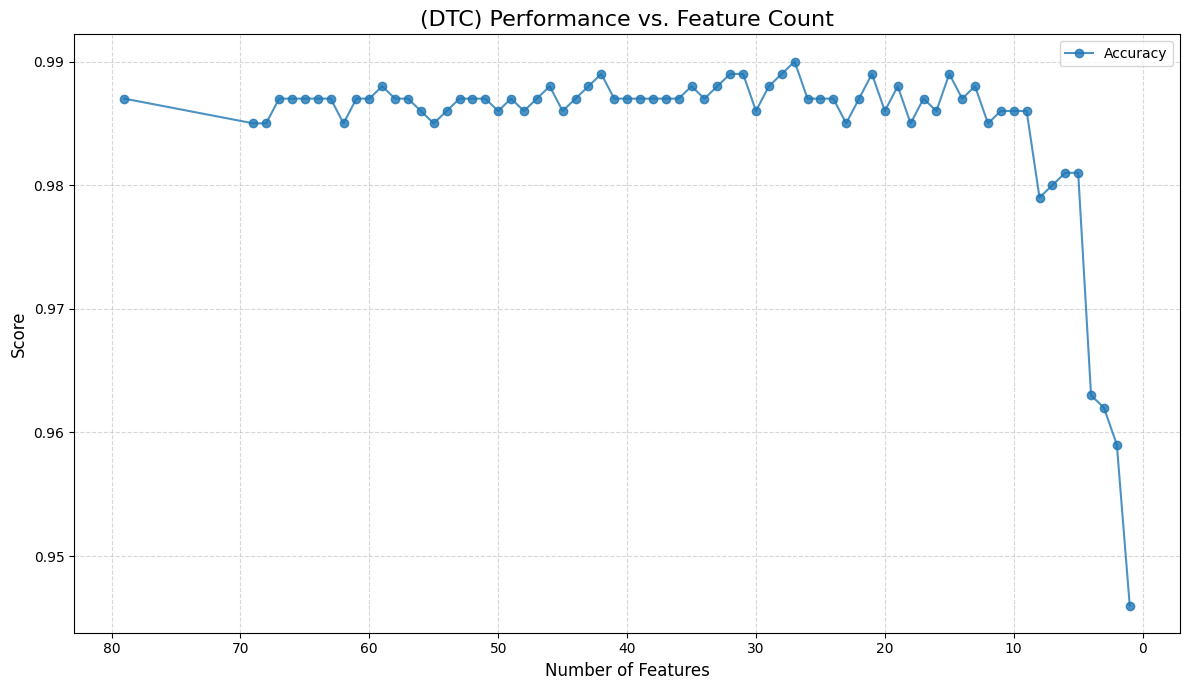

In [88]:
from matplotlib.ticker import ScalarFormatter

# Load and sort the data
graph_df = pd.read_csv('models_2512292131/rfc_2512292131/results.csv', engine='pyarrow')
graph_df = graph_df.sort_values(by='num_features')

# Create the plot
plt.figure(figsize=(12, 7))

plt.plot(graph_df['num_features'], graph_df['accuracy'], marker='o', label='Accuracy', alpha=0.8)

# Plot formating
plt.gca().invert_xaxis()

plt.title('(DTC) Performance vs. Feature Count', fontsize=16)
plt.xlabel('Number of Features', fontsize=12)
plt.ylabel('Score', fontsize=12)

# Ensure the log axis shows actual integers instead of powers of 10 (10^2, etc.)
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.gca().xaxis.set_minor_formatter(ScalarFormatter())

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='best')
plt.tight_layout()

plt.show()

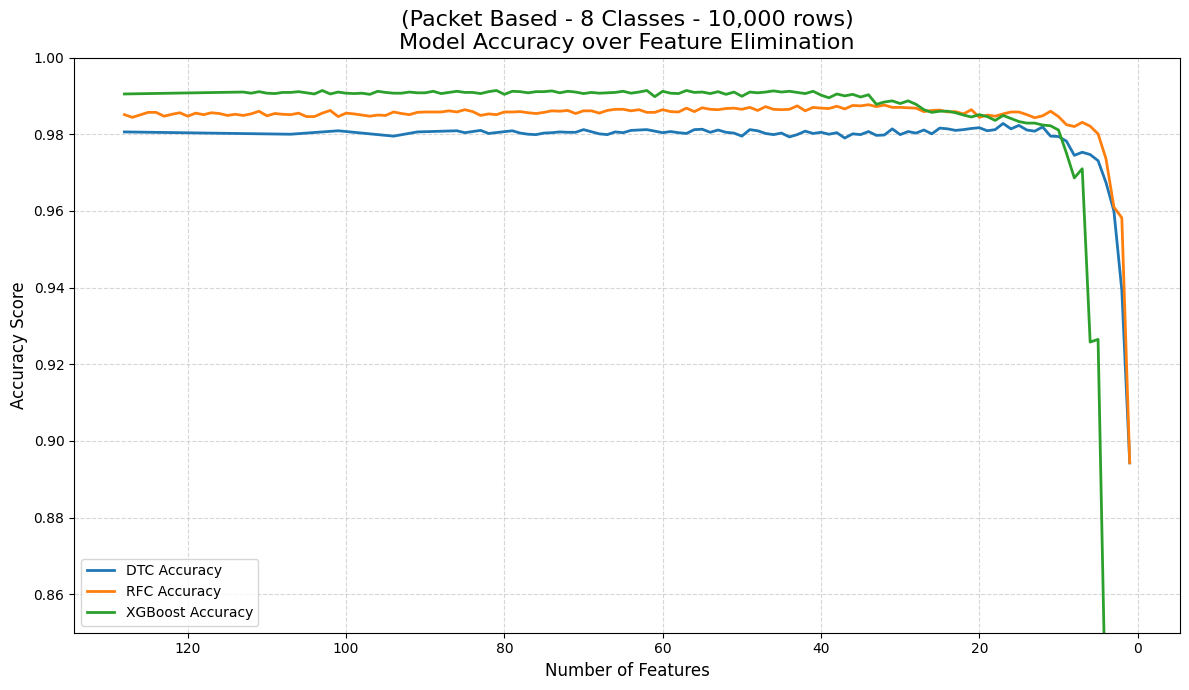

In [16]:
import pandas as pd

from matplotlib.ticker import ScalarFormatter


# Load the results
path_dtc = 'Graphing/dtc_results.csv'
path_rfc = 'Graphing/rfc_results.csv'
path_xgb = "Graphing/xgb_results.csv"
df_dtc = pd.read_csv(path_dtc).sort_values(by='num_features')
df_rfc = pd.read_csv(path_rfc).sort_values(by='num_features')
df_xgb = pd.read_csv(path_xgb).sort_values(by='num_features')

# Make the plot
plt.figure(figsize=(12, 7))
plt.plot(df_dtc['num_features'], df_dtc['accuracy'], 
         marker='', label='DTC Accuracy', linewidth=2, linestyle='-')
plt.plot(df_rfc['num_features'], df_rfc['accuracy'], 
         marker='', label='RFC Accuracy', linewidth=2, linestyle='-')
plt.plot(df_xgb['num_features'], df_xgb['accuracy'], 
         marker='', label='XGBoost Accuracy', linewidth=2, linestyle='-')

# Axis Formatting
# plt.yscale('log')
plt.gca().invert_xaxis()      # Invert so high feature counts are on the left
plt.gca().set_ylim(0.85, 1.0)
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.gca().xaxis.set_minor_formatter(ScalarFormatter())

# Labels and Style
plt.title(f'(Packet Based - 8 Classes - 10,000 rows)\nModel Accuracy over Feature Elimination', fontsize=16)
plt.xlabel('Number of Features', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='best')
plt.tight_layout()

# Show plot
plt.show()

***

# Variable Testing:

A section for testing and exploring errors, variables, features, processes, and functions.

In [ ]:
def scan_dataset_structure(root_path="./Dataset"):
    """
    Scans the directory tree and identifies folders containing .csv files.
    Returns a dictionary compatible with the NetworkAutoML data_config.
    """
    data_config = {}
    
    print(f"[*] Scanning {root_path} for sub-datasets...")
    
    for root, dirs, files in os.walk(root_path):
        # Filter for CSV files in the current folder
        csv_files = [f for f in files if f.endswith('.csv')]
        
        # If this folder contains CSVs, it's a potential class
        if csv_files:
            # We want the "bottom layer", so we check if this folder has 
            # subdirectories that also contain CSVs. If not, it's a leaf.
            has_csv_subdirs = False
            for d in dirs:
                subdir_path = os.path.join(root, d)
                for _, _, sub_f in os.walk(subdir_path):
                    if any(sf.endswith('.csv') for sf in sub_f):
                        has_csv_subdirs = True
                        break
                if has_csv_subdirs: break
            
            # If it's a leaf node containing data
            if not has_csv_subdirs:
                # Generate a unique label based on the folder hierarchy
                # e.g., 'Flow_Based_DDoS_ACK_Fragmentation'
                rel_path = os.path.relpath(root, root_path)
                label = rel_path.replace(os.sep, '_').replace(' ', '_')
                
                # Clean filenames for the previous dictionary format (remove .csv)
                filenames = [f.replace('.csv', '') for f in csv_files]
                
                # Store in config: { label: (path, [files]) }
                # Ensure path ends with a separator
                folder_path = root if root.endswith(os.sep) else root + os.sep
                data_config[label] = (folder_path, filenames)
                
                print(f"    [+] Found Class: {label} ({len(filenames)} files)")

    print(f"[*] Scan complete. Identified {len(data_config)} distinct classes.")
    return data_config

# --- Usage Example ---
# config = scan_dataset_structure("./Dataset")
# automl = NetworkAutoML(data_config=config, total_entries=50000)

In [ ]:
dataset_test = scan_dataset_structure("Dataset/")
print(dataset_test)